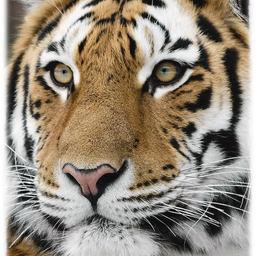

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import random

filename = r"C:\Users\ZiganshinShamil\Desktop\Study\Machine learning start\libraries\pillow\images\256x256_tiger.png"

with Image.open(filename) as img:
    img.load()

img


## Дискретизация сигнала 
– разбиение непрерывного сигнала на «выборки» (sampling, sampling rate)

256×256 → 128×128 → 64×64 → 8×8

Идея: берём непрерывное изображение и выбираем только определённые точки (пиксели) через равные интервалы.

Размеры оригинального изображения:  (256, 256, 3)
Sampling с шагом 2 :  (128, 128, 3)
Sampling с шагом 4 :  (64, 64, 3)
Sampling с шагом 8 :  (32, 32, 3)


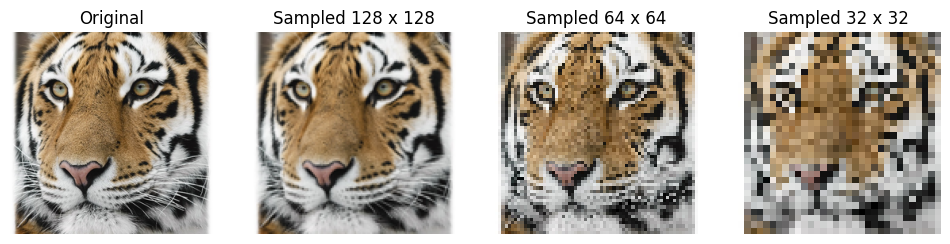

In [34]:
#arr[start:stop:step]
#arr[строки, столбцы]

arr = np.array(img)
arr.shape

# Уменьшим изобардение до 128 x 128
step = 2
sampled_128x128 = arr[::step, ::step]
img_sampled_128x128 = Image.fromarray(sampled_128x128) # объект изображения из массива numpy

# Уменьшим изобардение до 128 x 128
step = 4
sampled_64x64 = arr[::step, ::step]
img_sampled_64x64 = Image.fromarray(sampled_64x64)

# Уменьшим изобардение до 128 x 128
step = 8
sampled_32x32 = arr[::step, ::step]
img_sampled_32x32 = Image.fromarray(sampled_32x32)

print("Размеры оригинального изображения: ", arr.shape)
print("Sampling с шагом 2 : ", sampled_128x128.shape)
print("Sampling с шагом 4 : ", sampled_64x64.shape)
print("Sampling с шагом 8 : ", sampled_32x32.shape)

plt.figure(figsize=(12, 3)) # размеры в дюймах

plt.subplot(1, 4, 1)
plt.imshow(img, cmap="gray") # говорим что оно черно-белое
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2) # первые два числа говорят о том насколько мы делим нашу карту, а третья говорит в какой номер запихнуть изображение
plt.imshow(img.resize((128, 128)), cmap="gray")
plt.title("Sampled 128 x 128")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(img_sampled_64x64, cmap="gray")
plt.title("Sampled 64 x 64")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(img_sampled_32x32, cmap="gray")
plt.title("Sampled 32 x 32")
plt.axis("off")

plt.show()

# но базово делается это через
# img.resize((128, 128))

## Quantization (квантование)

Аналогия: У тебя есть коробка с 1000 разных мелков (исходное изображение). Тебе говорят: «Оставь только 16 самых нужных, а всё остальное рисуй ими». Ты выкидываешь 984 мелка и рисуешь картину только 16-ю. Детализация хуже, возможны пятна одного цвета, но картинка в целом узнаваема и весит в разы меньше. Это и есть квантование.


Квантование выборки – кодирование аналогового сигнала в дискретные величины (quantization)

In [35]:
# 2 Конвертируем в режим, который поддерживает квантование

# Квантование до 64 цветов
img_quantized_2 = img.convert('P', palette=Image.Palette.ADAPTIVE, colors=2)
img_quantized_3 = img.convert('P', palette=Image.Palette.ADAPTIVE, colors=3)
img_quantized_4 = img.convert('P', palette=Image.Palette.ADAPTIVE, colors=4)
img_quantized_8 = img.convert('P', palette=Image.Palette.ADAPTIVE, colors=8)
img_quantized_16 = img.convert('P', palette=Image.Palette.ADAPTIVE, colors=16)
img_quantized_256 = img.convert('P', palette=Image.Palette.ADAPTIVE, colors=256)

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

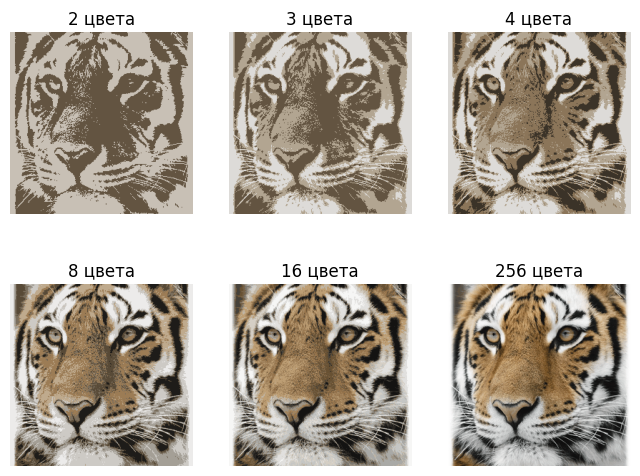

In [36]:
plt.figure(figsize=(8, 6)) # размеры в дюймах

plt.subplot(2, 3, 1)
plt.imshow(img_quantized_2)
plt.title("2 цвета")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(img_quantized_3)
plt.title("3 цвета")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(img_quantized_4)
plt.title("4 цвета")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(img_quantized_8)
plt.title("8 цвета")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(img_quantized_16)
plt.title("16 цвета")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(img_quantized_256)
plt.title("256 цвета")
plt.axis("off")

## Преобразование в оттенки серого

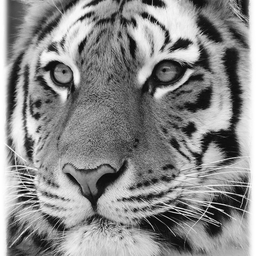

In [37]:
r, g, b = img.split()

r_arr = np.array(r, dtype=np.float32)
g_arr = np.array(g, dtype=np.float32)
b_arr = np.array(b, dtype=np.float32)

gray_arr = ((r_arr + g_arr + b_arr) / 3).astype(np.uint8)

# .astype это преобразование типа данных. Из дробных чисел (float) в целые беззнаковые
# 8-битные (0-255), которые понимает PIL для изображений

img_gray = Image.fromarray(gray_arr, mode='L') # здесь L говорит о том что не нужно ничего преобразовывать, наши данные уже 8-битные

img_gray

## Fixed Thresholding (Пороговая бинаризация) 

всё, что светлее порога, становится белым, всё темнее — чёрным

Сначала сделаем изображение черно-белым

У меня есть цветной пиксель: (R, G, B), где каждый компонент от 0 до 255.

(R+G+B)/3

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

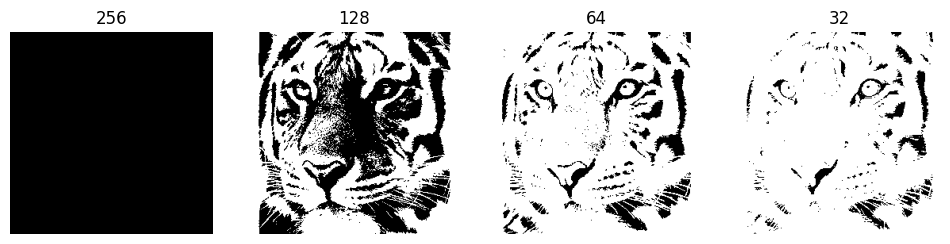

In [38]:
r, g, b = img.split()

r_arr = np.array(r, dtype=np.float32)
g_arr = np.array(g, dtype=np.float32)
b_arr = np.array(b, dtype=np.float32)

gray_arr = ((r_arr + g_arr + b_arr) / 3).astype(np.uint8)

# .astype это преобразование типа данных. Из дробных чисел (float) в целые беззнаковые
# 8-битные (0-255), которые понимает PIL для изображений

img_gray = Image.fromarray(gray_arr, mode='L') # здесь L говорит о том что не нужно ничего преобразовывать, наши данные уже 8-битные

# 3. Бинаризация: всё что >= порога = белое (255), остальное = чёрное (0)
binary_image_256 = img_gray.point(lambda x: 255 if x >= 256 else 0) # 256 128 64 32 - средние значения
binary_image_128 = img_gray.point(lambda x: 255 if x >= 128 else 0)
binary_image_64 = img_gray.point(lambda x: 255 if x >= 64 else 0)
binary_image_32 = img_gray.point(lambda x: 255 if x >= 32 else 0)

plt.figure(figsize=(12, 3)) # размеры в дюймах

plt.subplot(1, 4, 1)
plt.imshow(binary_image_256, cmap="gray")
plt.title("256")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(binary_image_128, cmap="gray")
plt.title("128")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(binary_image_64, cmap="gray")
plt.title("64")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(binary_image_32, cmap="gray")
plt.title("32")
plt.axis("off")

## Random Thresholding



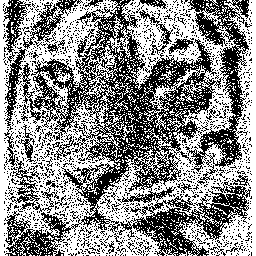

In [53]:
# 3. Бинаризация: всё что >= порога = белое (255), остальное = чёрное (0)
binary_image_random = img_gray.point(lambda x: 255 if x >= random.randint(0, 255) else 0) 

binary_image_random

## Дизеринг Байера

Bayer2 = [[0, 2],
          [3, 1]]


Выражение i % n, j % n

% n = остаток от деления

Для 2×2 матрицы n=2, так что остаток всегда 0 или 1

Это позволяет повторять матрицу на всю картинку:

i=0 → i%n = 0

i=1 → i%n = 1

i=2 → i%n = 0

i=3 → i%n = 1


То же самое с j.

Таким образом можем одновременно проходит и по нащему массиву(изображению) и по матрице байера

In [40]:
# Сделаем серое изображение с разрешением 256 и 64
# 256
r, g, b = img.split()
r_arr = np.array(r, dtype=np.float32)
g_arr = np.array(g, dtype=np.float32)
b_arr = np.array(b, dtype=np.float32)

gray_arr = ((r_arr + g_arr + b_arr) // 3).astype(np.uint8)
img_gray_256 = Image.fromarray(gray_arr, mode='L')


# 64
r, g, b = img_sampled_64x64.split()
r_arr = np.array(r, dtype=np.float32)
g_arr = np.array(g, dtype=np.float32)
b_arr = np.array(b, dtype=np.float32)

gray_arr = ((r_arr + g_arr + b_arr) // 3).astype(np.uint8)
img_gray_64 = Image.fromarray(gray_arr, mode='L')

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

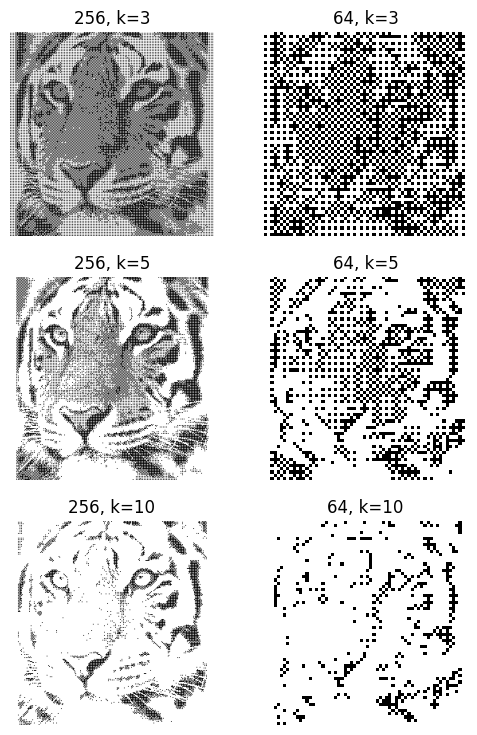

In [41]:
# Определяем матрицу 2x2
m_2x2 = np.array([[0, 2],
                  [3, 1]])


def bayer(img_, k):
    # ----------------
    # Для любого разрешениz
    arr_256 = np.array(img_, dtype=np.float32)

    dithered_256 = np.zeros_like(arr_256, dtype=np.uint8)

    for y in range(arr_256.shape[0]):
        for x in range(arr_256.shape[1]):
            if arr_256[y, x] * k / 256 > m_2x2[y % 2, x % 2]:
                dithered_256[y, x] = 255
            else:
                dithered_256[y, x] = 0

    return Image.fromarray(dithered_256, mode="L")

# 5
img_dithered_64_5 = bayer(img_gray_64, k=5)
img_dithered_256_5 = bayer(img_gray_256, k=5)

# 3
img_dithered_64_3 = bayer(img_gray_64, k=3)
img_dithered_256_3 = bayer(img_gray_256, k=3)

# 10
img_dithered_64_10 = bayer(img_gray_64, k=10)
img_dithered_256_10 = bayer(img_gray_256, k=10)

# ----------------
# Визуализация джл 5
plt.figure(figsize=(6, 9))

plt.subplot(3, 2, 1)
plt.imshow(img_dithered_256_3, cmap="gray")
plt.title("256, k=3")
plt.axis("off")

plt.subplot(3, 2, 2)
plt.imshow(img_dithered_64_3, cmap="gray")
plt.title("64, k=3")
plt.axis("off")

plt.subplot(3, 2, 3)
plt.imshow(img_dithered_256_5, cmap="gray")
plt.title("256, k=5")
plt.axis("off")

plt.subplot(3, 2, 4)
plt.imshow(img_dithered_64_5, cmap="gray")
plt.title("64, k=5")
plt.axis("off")

plt.subplot(3, 2, 5)
plt.imshow(img_dithered_256_10, cmap="gray")
plt.title("256, k=10")
plt.axis("off")

plt.subplot(3, 2, 6)
plt.imshow(img_dithered_64_10, cmap="gray")
plt.title("64, k=10")
plt.axis("off")

In [42]:
# Демонстрация
img_dithered_256_5.show()

### Дизеринг с рассеянием ошибки по алгоритму Floyd-Steinberg
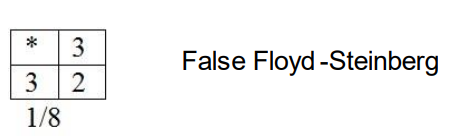

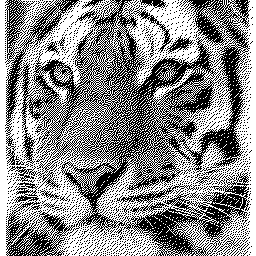

In [58]:
def floyd_steinberg_custom(img_):
    arr_256 = np.array(img_, dtype=np.float32)
    dithered_256 = np.zeros_like(arr_256, dtype=np.uint8)
    h, w = arr_256.shape

    for y in range(h):
        for x in range(w):
            old_pixel = arr_256[y, x]
            new_pixel = 255 if old_pixel > 127 else 0
            dithered_256[y, x] = new_pixel
            error = old_pixel - new_pixel

            if x + 1 < w:
                arr_256[y, x + 1] += error * 3 / 8

            if y + 1 < h:
                arr_256[y + 1, x] += error * 3 / 8

                if x + 1 < w:
                    arr_256[y + 1, x + 1] += error * 2 / 8

    return Image.fromarray(dithered_256, mode="L")


img_mat = floyd_steinberg_custom(img_gray_256)
img_mat

In [ ]:
# img_mat.show()